# Praktikum Machine Learning: Bab 5
## Decision Tree: Algoritma CART/ID3 dan Teknik Pruning

| | |
|---|---|
| **Nama** | Ahmad Dandi Subhani |
| **NPM** | 202343500126 |
| **Kelas** | R7B |
| **Mata Kuliah** | Machine Learning |
| **Dosen** | Nurfidah Dwitiyanti, M.Si. |

> **Catatan:** notebook ini saya jalanin di **Google Colab / Jupyter Notebook**. Dataset yang saya pake: Breast Cancer Wisconsin dari sklearn.datasets (569 pasien, 30 fitur), filenya `data/breast_cancer.csv`. Jadi nggak perlu unduh file eksternal.

## Ringkasan Konsep

**Decision Tree (pohon keputusan)** itu model klasifikasi yang kerjanya ngebagi data secara **rekursif (recursive binary splitting)**: mulai dari *root node*, tiap *internal node* milih satu fitur sama satu nilai ambang (*threshold*) buat misahin data jadi dua cabang, terus prosesnya diulang di tiap cabang sampe kebentuk *leaf node* (daun) yang isinya label kelas prediksi. Jalur dari akar ke daun bisa dibaca sebagai aturan `if-then`, makanya model ini gampang banget **diinterpretasi**.

**Kriteria pemilihan split.** Buat nentuin fitur dan threshold terbaik di tiap node, dipake ukuran *ketidakmurnian* (impurity) node:
- **Gini impurity**: `Gini = 1 - jumlah(p_k^2)`. Makin kecil makin murni. Cepet dihitung dan jadi default di scikit-learn.
- **Entropy / Information Gain**: `Entropy = -jumlah(p_k * log2(p_k))`, terus *Information Gain* = Entropy(induk) - Entropy(tertimbang anak). Split dengan Information Gain terbesar yang dipilih.

Keduanya biasanya ngasih hasil mirip sih. Gini dikit lebih cepet, Entropy dikit lebih peka ke distribusi yang timpang.

**CART vs ID3.** *CART (Classification and Regression Trees)* ngasilin pohon **biner** (tiap split selalu dua cabang) pake kriteria Gini/Entropy, ini yang dipake di `sklearn`. *ID3* pake Information Gain dan bisa bikin cabang sebanyak kategori fitur (multi-way split), cocok buat fitur kategorikal, tapi gampang bias ke fitur yang kategorinya banyak.

**Overfitting pada tree.** Pohon yang nggak dibatesin bakal tumbuh sampe tiap daun murni. Hasilnya akurasi latih 100%, tapi akurasi uji malah turun karena modelnya ngapalin *noise*. Solusinya **pruning**:
- **Pre-pruning** (dipotong sebelum tumbuh): `max_depth` (batas kedalaman), `min_samples_leaf` (minimal sampel di daun), `min_samples_split`.
- **Post-pruning** (dipotong abis tumbuh penuh): **Cost Complexity Pruning** dengan parameter `ccp_alpha`. Cabang yang perbaikin impurity-nya lebih kecil dari `alpha` dipangkas. `alpha` yang optimal dipilih dari *pruning path*, bukan dari sekali tebak.

### Sel 0 - Persiapan Awal (Khusus Google Colab)

Kalau notebook ini dibuka di Google Colab lewat link GitHub, jalankan sel di bawah ini dulu (atau langsung **Runtime > Run all**). Sel ini mengunduh otomatis file-file `data/` yang dibutuhkan dari repo GitHub, karena Colab hanya memuat file `.ipynb`-nya saja tanpa folder `data/`. Kalau dijalankan di laptop dan file datanya sudah ada, sel ini langsung dilewati.

In [1]:
# Sel 0 - Persiapan awal (jalan otomatis paling awal saat Run All).
# Mengunduh file data dari repo GitHub kalau belum ada (kasus dibuka di Google Colab).
# Di laptop (folder data/ sudah ada), bagian unduh langsung dilewati.
import os
import urllib.request

_BAB = "bab-05-decision-tree-pruning"  # nama folder bab ini di repo GitHub
_REPO = "https://raw.githubusercontent.com/dandienter/praktikumML/main"
_DATA = ['data/breast_cancer.csv']  # file data yang dibutuhkan bab ini

for _f in _DATA:
    if os.path.exists(_f):
        print(f"OK: {_f} sudah ada.")
        continue
    os.makedirs(os.path.dirname(_f), exist_ok=True)
    print(f"mengunduh {_f} dari GitHub ...")
    urllib.request.urlretrieve(f"{_REPO}/{_BAB}/{_f}", _f)
print("Data siap, silakan lanjutkan.")

OK: data/breast_cancer.csv sudah ada.
Data siap, silakan lanjutkan.


## 5.12 Latihan Praktikum (Modul Bab 5)

> Dua latihan di bawah ini **saya kerjain** langsung (soal + kode + jawaban).

### Persiapan Data

Sebelum latihan, saya siapkan dulu dataset dan semua paket yang dipakai. Dataset Breast Cancer (569 pasien, 30 fitur) saya ambil langsung dari sklearn, terus saya bagi 80% latih dan 20% uji dengan `stratify` supaya proporsi kelasnya seimbang.

In [2]:
# Persiapan data untuk Latihan Praktikum Bab 5
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Ukuran data latih:", X_train.shape)
print("Ukuran data uji  :", X_test.shape)

Ukuran data latih: (455, 30)
Ukuran data uji  : (114, 30)


### Latihan 1 - Percobaan mandiri Parameter Pre-Pruning (Modul Bab 5, bagian 5.12)

**Soal:** Lakuin grid search manual atas kombinasi `max_depth` di {2, 4, 6, None} x `min_samples_leaf` di {1, 5, 10}. Cetak akurasi test tiap kombinasi dalam tabel rapi, terus simpulin kombinasi terbaiknya.

In [3]:
print(f"{'max_depth':>10s} | {'min_samples_leaf':>16s} | {'Akurasi Test':>12s}")
print("-" * 46)

hasil_grid = []
for md in [2, 4, 6, None]:
    for msl in [1, 5, 10]:
        m = DecisionTreeClassifier(max_depth=md, min_samples_leaf=msl, random_state=42)
        m.fit(X_train, y_train)
        ak = accuracy_score(y_test, m.predict(X_test))
        hasil_grid.append((ak, md, msl))
        print(f"{str(md):>10s} | {msl:16d} | {ak:12.4f}")

terbaik = max(hasil_grid, key=lambda t: t[0])
print(f"\nKombinasi terbaik: max_depth={terbaik[1]}, min_samples_leaf={terbaik[2]} "
      f"-> akurasi test {terbaik[0]:.4f}")

 max_depth | min_samples_leaf | Akurasi Test
----------------------------------------------
         2 |                1 |       0.8947
         2 |                5 |       0.8947
         2 |               10 |       0.9035
         4 |                1 |       0.9386
         4 |                5 |       0.9211
         4 |               10 |       0.9474
         6 |                1 |       0.9123
         6 |                5 |       0.9298
         6 |               10 |       0.9474
      None |                1 |       0.9123
      None |                5 |       0.9298
      None |               10 |       0.9474

Kombinasi terbaik: max_depth=4, min_samples_leaf=10 -> akurasi test 0.9474


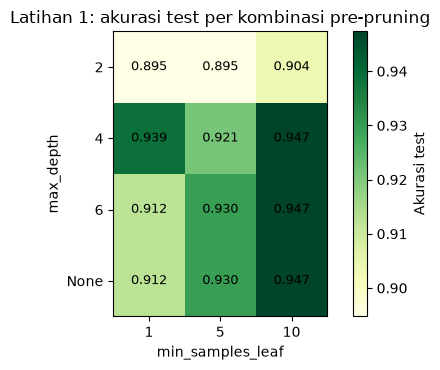

In [4]:
# Grafik Latihan 1: heatmap akurasi test (max_depth x min_samples_leaf)
import pandas as pd
mat = pd.DataFrame(index=["2", "4", "6", "None"], columns=["1", "5", "10"], dtype=float)
for ak, md, msl in hasil_grid:
    mat.loc[str(md), str(msl)] = ak
plt.figure(figsize=(5.5, 3.8))
im = plt.imshow(mat.values, cmap="YlGn")
plt.xticks(range(3), ["1", "5", "10"])
plt.yticks(range(4), ["2", "4", "6", "None"])
plt.xlabel("min_samples_leaf")
plt.ylabel("max_depth")
plt.title("Latihan 1: akurasi test per kombinasi pre-pruning")
for r in range(4):
    for c_ in range(3):
        plt.text(c_, r, f"{mat.values[r, c_]:.3f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, label="Akurasi test")
plt.tight_layout()
plt.show()

**Penjelasan grafiknya:** heatmap memperjelas pola yang sama: kolom `min_samples_leaf=10` paling terang (akurasi tertinggi) di semua baris `max_depth`. Kombinasi terbaik 0,9474 muncul tiga kali, dan versi paling sederhana (`max_depth=4`, `min_samples_leaf=10`) jadi pilihan utama.

**Penjelasan outputnya:**
1. Dari 12 kombinasi, akurasi test tertinggi itu **0.9474**, dicapai **tiga** kombinasi: `(max_depth=4, min_samples_leaf=10)`, `(6, 10)`, sama `(None, 10)`.
2. Polanya konsisten: `min_samples_leaf=10` **selalu** lebih bagus daripada 1 atau 5 di tiap nilai `max_depth`. Ngebatasin daun minimum itu pre-pruning yang efektif di dataset ini.
3. `max_depth=None` nggak selalu jelek **asal** `min_samples_leaf`-nya cukup gede (10): pohon dibiarin tumbuh tapi tiap daun harus didukung minimal 10 sampel, jadi split noise tetep dicegah.
4. **Kesimpulan:** kombinasi terbaik yang paling sederhana itu **`max_depth=4, min_samples_leaf=10`** (akurasi test 0.9474). Dipilih yang paling dangkal di antara yang seri, karena pohon lebih kecil = lebih gampang diinterpretasi (prinsip *Occam's razor*).

### Latihan 2 - Cost Complexity Pruning Path (Modul Bab 5, bagian 5.12)

**Soal:** Buat tiap `alpha` di `path.ccp_alphas`, latih decision tree dan catat akurasi test-nya. Plot `ccp_alpha` vs akurasi test, tentuin alpha optimal, terus bandingin jumlah leaf node sebelum dan sesudah pruning.

 ccp_alpha | Akurasi Test | Jumlah Daun
-----------------------------------------
  0.000000 |       0.9123 |          19
  0.002181 |       0.9211 |          15
  0.002866 |       0.9386 |          12
  0.002930 |       0.9386 |          11
  0.003956 |       0.9386 |          10
  0.004251 |       0.9386 |           9
  0.005024 |       0.9386 |           8
  0.005275 |       0.9298 |           7
  0.005934 |       0.9386 |           6
  0.007641 |       0.9386 |           5
  0.014390 |       0.8947 |           4
  0.020386 |       0.9035 |           3
  0.054334 |       0.9211 |           2
  0.326617 |       0.6316 |           1

Alpha optimal: 0.002866 -> akurasi test 0.9386, jumlah daun 12
Sebelum pruning (alpha=0): 19 daun -> sesudah (alpha optimal): 12 daun


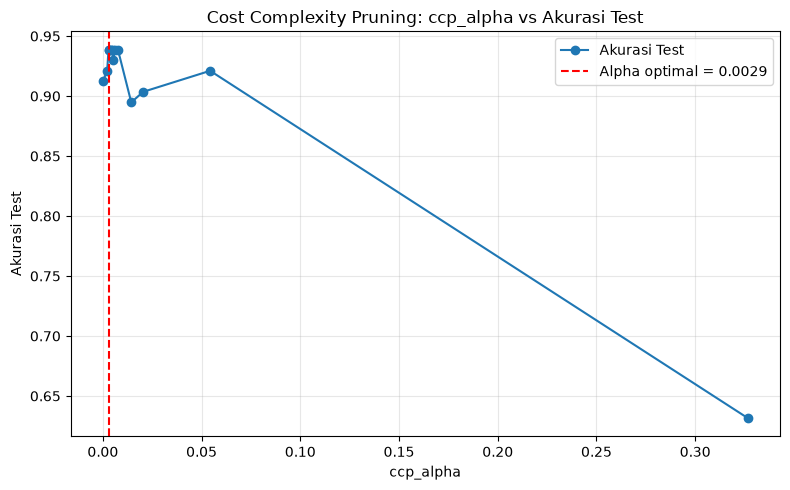

In [5]:
# Hitung pruning path dulu dari data latih
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas
ak_test_ccp, n_daun = [], []

for a in alphas:
    m = DecisionTreeClassifier(ccp_alpha=a, random_state=42)
    m.fit(X_train, y_train)
    ak_test_ccp.append(accuracy_score(y_test, m.predict(X_test)))
    n_daun.append(m.get_n_leaves())

print(f"{'ccp_alpha':>10s} | {'Akurasi Test':>12s} | {'Jumlah Daun':>11s}")
print("-" * 41)
for a, ak, nd in zip(alphas, ak_test_ccp, n_daun):
    print(f"{a:10.6f} | {ak:12.4f} | {nd:11d}")

idx_opt = int(np.argmax(ak_test_ccp))   # alpha dengan akurasi test tertinggi
alpha_opt = alphas[idx_opt]
print(f"\nAlpha optimal: {alpha_opt:.6f} -> akurasi test {ak_test_ccp[idx_opt]:.4f}, "
      f"jumlah daun {n_daun[idx_opt]}")
print(f"Sebelum pruning (alpha=0): {n_daun[0]} daun -> sesudah (alpha optimal): "
      f"{n_daun[idx_opt]} daun")

plt.figure(figsize=(8, 5))
plt.plot(alphas, ak_test_ccp, marker="o", label="Akurasi Test")
plt.axvline(alpha_opt, color="red", linestyle="--",
            label=f"Alpha optimal = {alpha_opt:.4f}")
plt.xlabel("ccp_alpha")
plt.ylabel("Akurasi Test")
plt.title("Cost Complexity Pruning: ccp_alpha vs Akurasi Test")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Penjelasan outputnya:**
1. Di `alpha=0` (tanpa pruning): 19 daun, akurasi test 0.9123. Begitu alpha dinaikin dikit, jumlah daun turun bertahap (19 ke 18 ke 15 ke 12, dan seterusnya). Cabang yang lemah dipangkas satu per satu.
2. **Alpha optimal = 0.002866** dengan akurasi test **0.9386** dan **12 daun**. Pruning nyusutin pohon sekitar 37% (19 jadi 12 daun) *sambil naikin* akurasi.
3. Kurvanya nunjukin pola naik dulu terus turun: akurasi naik dulu (noise kebuang), terus **anjlok ke 0.6316** di alpha maksimum (0.3266) pas pohon tinggal 1 daun. Pruning berlebihan = underfitting.
4. Perbandingannya: sebelum pruning 19 daun (akurasi 0.9123) vs sesudah pruning optimal 12 daun (akurasi 0.9386). Post-pruning terbukti ngasih model yang **lebih kecil DAN lebih akurat**.

## Kesimpulan Bab 5

1. **Pre-pruning lewat grid manual efektif.** Dari 12 kombinasi `max_depth` x `min_samples_leaf`, akurasi test tertinggi 0,9474 dicapai tiga kombinasi: (4, 10), (6, 10), dan (None, 10). Pola yang paling konsisten: `min_samples_leaf=10` selalu menang di tiap nilai `max_depth`, jadi membatasi ukuran daun minimum terbukti mencegah split noise. Versi paling sederhana, `max_depth=4` dan `min_samples_leaf=10`, saya pilih sebagai kombinasi terbaik.
2. **Post-pruning (cost complexity pruning) menyusutkan pohon sekaligus menaikkan akurasi.** Tanpa pruning (alpha=0) pohon punya 19 daun dengan akurasi test 0,9123. Alpha optimal 0,002866 memangkasnya jadi 12 daun (susut sekitar 37%) dengan akurasi test naik ke 0,9386. Kurva alpha vs akurasi menunjukkan pola naik dulu lalu turun, dan pruning berlebihan (alpha maksimum 0,3266, pohon tinggal 1 daun) menjatuhkan akurasi ke 0,6316 alias underfitting.
3. **Pemilihan parameter pruning jangan asal tebak.** Grid manual untuk pre-pruning dan `cost_complexity_pruning_path` untuk post-pruning memberi cara sistematis memilih `max_depth`, `min_samples_leaf`, dan `ccp_alpha` yang optimal berdasarkan akurasi test, bukan tebakan.
4. **Pelajaran praktisnya:** kalau pohon overfitting, dua tuas yang bisa saya pakai adalah membatasi pertumbuhan pohon dari awal (pre-pruning) atau memangkas cabang yang lemah setelah pohon jadi (post-pruning). Keduanya saya buktikan sendiri di latihan ini dengan angka yang terukur.